# Figure 1 K-M: Freely moving augmented reality, system and performance

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-02-13 16:45:56,107::INFO::settings.py::Setting loglevel to INFO
2025-02-13 16:45:56,108::INFO::settings.py::Setting stores to {}
2025-02-13 16:45:56,109::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-13 16:45:56,110::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-13 16:45:56,110::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-13 16:45:56,111::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-13 16:45:56,112::INFO::settings.py::Setting database.user to celia
2025-02-13 16:45:56,113::INFO::settings.py::Setting database.password to celia_mathislab
2025-02-13 16:45:56,246::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-13 16:45:56,360::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:56,782::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:56,782::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:57,335::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:57,335::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:57,487::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:57,487::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:57,819::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:57,819::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:58,170::INFO::table.py::could not log event in table ~log
2025-02-13 16:45:58,170::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
style()

In [5]:
save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [6]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns=['head_center_x', 'head_center_y', 
                                                                                 'heading_dir', 'head_angle', 
                                                                                 'pose_time', 'step_time', 'step'])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = pd.concat([df, offline_kinematics_df], axis=1)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    
    #big_df["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1) # this is wrong.
    big_df["session_increment"] = big_df.groupby("mouse_name")["dataset"].rank(method="dense", ascending=True).astype(int)
    
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [ ]:
dfs = []
for stage in ["ar_detection_no_velthr", "ar_detection_velthr", "ar_discrim"]:
    training = (vr4mice.Dataset() & f'session_label = "{stage}"') & (vr4mice.Collab() & 'idx=3')
    training_list = [{"dataset": x["dataset"]}for x in training]
    if {"dataset": 'Nightingale_2024-07-31_1'} in training_list: # mathis lab
        training_list.remove({"dataset": 'Nightingale_2024-07-31_1'})
    if {"dataset": 'tom_2024-11-01_1'} in training_list: # tolias lab
        training_list.remove({"dataset": 'tom_2024-11-01_1'})
    dfs.append(get_all_in_list(data_set_list = training_list, training_stage=stage))

big_df = pd.concat(dfs).reset_index(drop=True)

In [11]:
big_df.to_pickle("big_df_contrast_training_niell.pkl")

In [7]:
niell_data = pd.read_pickle("big_df_contrast_training_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_training.pkl")

big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

In [ ]:
def get_training_stage_per_mouse(big_df, mouse_name):
    new_df_list = []
    mouse_df = big_df[big_df.mouse_name == mouse_name].copy()
    
    df = mouse_df[(mouse_df.training_stage == "ar_detection_no_velthr")].copy()
    early = df[df.session_increment == df.session_increment.unique()[0]].copy()
    early["num_train_stage"] = 0
    new_df_list.append(early)
    
    mid = df[df.session_increment == df.session_increment.unique()[-1]].copy() #-2
    mid["num_train_stage"] = 1
    new_df_list.append(mid)
     
    df = mouse_df[(mouse_df.training_stage == "ar_detection_velthr")].copy()
    late = df[df.session_increment == df.session_increment.unique()[-1]].copy() #0
    late["num_train_stage"] = 2
    new_df_list.append(late)
    
    df = mouse_df[(mouse_df.training_stage == "ar_discrim")].copy()
    
    early = df[df.session_increment == df.session_increment.unique()[0]].copy()
    early["num_train_stage"] = 3
    new_df_list.append(early)

    late = df[df.session_increment == df.session_increment.unique()[-1]].copy() # 1
    late["num_train_stage"] = 5
    new_df_list.append(late)
    
    if len(df.session_increment.unique()) > 2:
        mid = df[df.session_increment == df.session_increment.unique()[-2]].copy()
        mid["num_train_stage"] = 4
        new_df_list.append(mid)
    return(pd.concat(new_df_list))


def training_plots(big_df, mouse_name, variable,  ax, ylim = (0.4,1), midpoint_line = True, 
                  criterion_line=True, ylabel="Success rate/session", xlabel= "Session", 
                  cmap = ["#3FB47C","#1F6F49", "#FF1493"], s=100):
    
    big_df = big_df.copy()
    mean_mouse = big_df.groupby(["mouse_name", "training_stage", "num_train_stage", "trial"],as_index=False).mean(numeric_only=True)
    mean_mouse = mean_mouse.groupby(["mouse_name", "training_stage", "num_train_stage"],as_index=False).mean(numeric_only=True)
    data = mean_mouse[mean_mouse.mouse_name == mouse_name].copy()
    sns.lineplot(data=data, x="num_train_stage",y= variable, color="black", legend=None, alpha=0.5, ax=ax)
    sns.scatterplot(data=data, x="num_train_stage",y= variable, hue="training_stage", 
                    palette=cmap, alpha=0.9,legend=None, zorder=100,s=s, ax=ax)

    if variable == "trial_rewarded": 
        ax.set_ylim(ylim[0], ylim[1])
        if midpoint_line:
            ax.axhline(0.5, linestyle="dashed", color="black", alpha=0.5)
        if criterion_line:
            ax.axhline(0.70, linestyle="dashed", color="red", alpha=0.3)
    if variable == "trial_count":
        ax.axhline(125, linestyle="dashed", color="red", alpha=0.3)
    
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    sns.despine(offset=10)
    
def days_in_training_stage(big_df, mouse_name):
    mean_mouse = big_df [big_df.mouse_name == mouse_name]
    mean_mouse = mean_mouse.groupby(["training_stage"], as_index=False)["session"].nunique()
    return(mean_mouse)

## Training task performance & training time

In [9]:
big_df = big_df[big_df.mouse_name != "Vegavis"]
big_df = big_df[big_df.dataset != 'Nightingale_2024-07-31_2']
big_df = big_df[big_df.dataset != 'Kiwi_2024-08-08_3']
big_df["session_increment"] = big_df.groupby("mouse_name")["dataset"].rank(method="dense", ascending=True).astype(int)

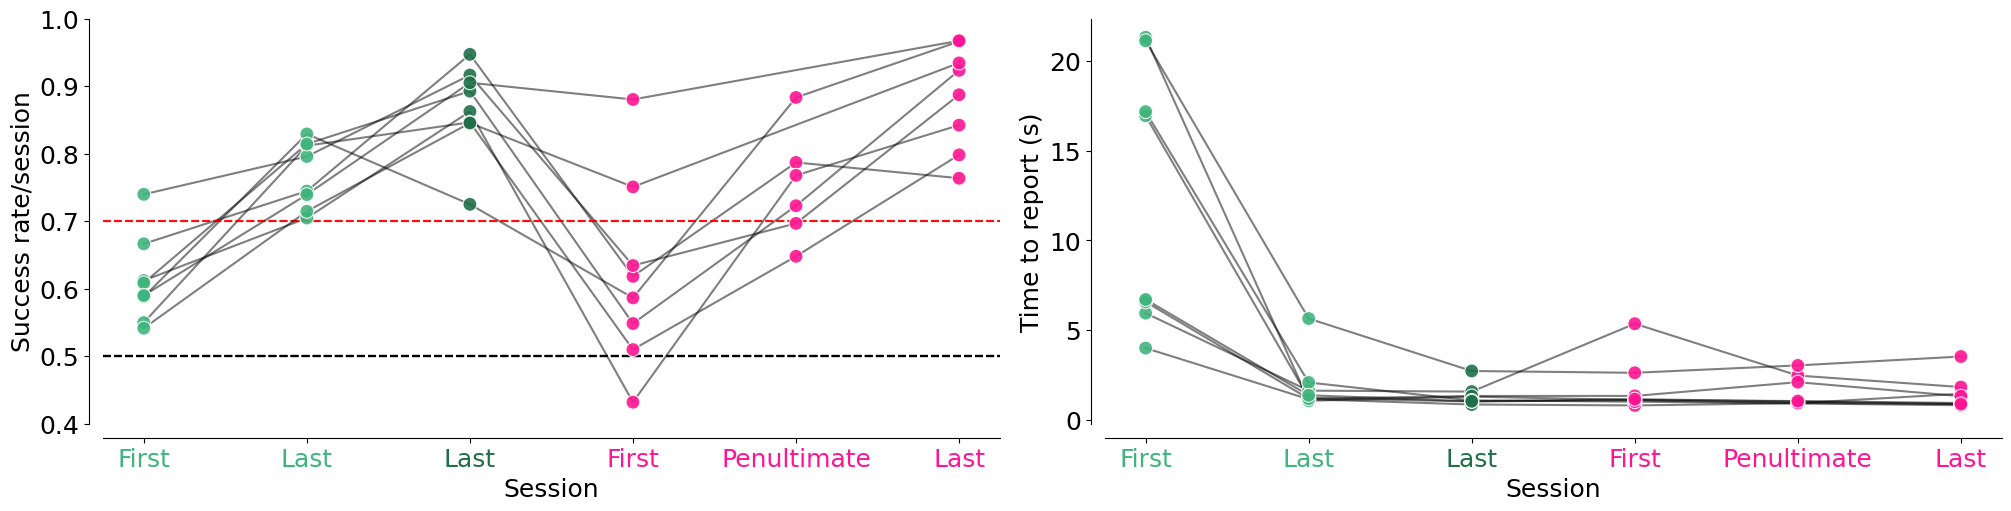

In [14]:
fig, ax = plt.subplots(1, 2,figsize=(20, 5), constrained_layout=True)
ax = ax.flatten()

for (i, variable), ylabel in zip(enumerate(["trial_rewarded", "trial_duration"]), ["Success rate/session", "Time to report (s)"]): 
    for mouse_name in big_df.mouse_name.unique():
        tmp_df = get_training_stage_per_mouse(big_df, mouse_name)
        training_plots(tmp_df, mouse_name=mouse_name, variable=variable, ax=ax[i], ylabel=ylabel)
    sns.despine(offset=10, ax=ax[i])

for i in range(2):
    # Define tick positions and labels
    stage_positions = np.arange(6)  # Adjust if needed
    stage_labels = ["First", "Last", "Last", "First", "Penultimate", "Last"]
    stage_colors = ["#3FB47C", "#3FB47C", "#1F6F49", "#FF1493", "#FF1493", "#FF1493"]

    ax[i].set_xticks(stage_positions)  
    ax[i].set_xticklabels(stage_labels, rotation=0, fontsize=18)  

    for j, label in enumerate(ax[i].get_xticklabels()):
        label.set_color(stage_colors[j])

    ax[i].figure.canvas.draw()

plt.savefig(save_fig_path + "training_success_and_time_figure1.svg", transparent=True)

## Total training days

mean:  13.375 
sem:  2.1459055697503824


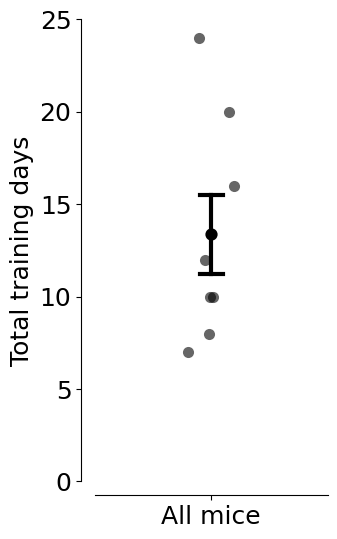

In [13]:
df = pd.DataFrame(big_df.groupby(["mouse_name"]).session_increment.nunique())

# Create a single category for all mice
df["group"] = "mice"

# Plot
plt.figure(figsize=(3,6))
sns.stripplot(x="group", y="session_increment", 
              data=df, color="black", 
              jitter=True,
              size=8, 
              alpha=0.6,
              zorder=1)
sns.pointplot(x="group", 
              y="session_increment",
              data=df, 
              join=False, 
              color="black", 
              markers="o", 
              errorbar="se",
              capsize=0.1,
              errwidth=3,
              zorder=2)

plt.xticks([0], ["All mice"])
plt.xlabel("")

plt.ylabel("Total training days")
plt.ylim(0, 25)
sns.despine(offset =10)

plt.savefig(save_fig_path + "training_days_figure1.svg", transparent=True)

print("mean: ", df.groupby("group")["session_increment"].mean().values[0], 
      "\nsem: ", df.groupby("group")["session_increment"].sem().values[0])